
# Q2：Agent 驱动的金融建模系统（方向 A）

## 结果索引
- **数据概况输出**：Cell `数据加载与概览`
- **训练过程输出**：Cell `运行 Agent 系统`
- **评估指标输出（AUC/Precision/Recall/F1）**：Cell `读取并展示核心指标`
- **可视化输出（混淆矩阵/ROC）**：Cell `展示可视化结果`
- **数据泄漏检查输出**：Cell `泄漏检查`


In [1]:

from pathlib import Path
import sys
ROOT = Path.cwd()
if (ROOT / 'Q2' / 'data').exists():
    REPO_ROOT = ROOT
elif (ROOT / 'data').exists() and ROOT.name == 'Q2':
    REPO_ROOT = ROOT.parent
else:
    REPO_ROOT = ROOT
sys.path.append(str(REPO_ROOT))
print('REPO_ROOT =', REPO_ROOT)


REPO_ROOT = /workspace/ai-data-science-team


In [2]:

# 数据加载与概览
import pandas as pd

data_files = sorted((REPO_ROOT / 'Q2' / 'data').glob('*.pq'))
df = pd.concat([pd.read_parquet(f) for f in data_files], ignore_index=True)
print('数据文件数:', len(data_files))
print('数据形状:', df.shape)
print('前12列:', df.columns[:12].tolist())
print('标签分布(Y1):')
print(df['Y1'].value_counts(dropna=False))


数据文件数: 9
数据形状: (81046, 321)
前12列: ['trade_date', 'underlying', 'start_time', 'end_time', 'open', 'high', 'low', 'close', 'volume', 'Y1', 'Y2', 'Y3']
标签分布(Y1):
Y1
-1.0    58257
 1.0    11779
 0.0    11010
Name: count, dtype: int64


In [3]:
# 运行 Agent 系统
from Q2.code.agent_feature_system import FinancialFeatureAgentSystem, AgentConfig
cfg = AgentConfig(
    data_dir=str(REPO_ROOT / 'Q2' / 'data'),
    output_dir=str(REPO_ROOT / 'Q2' / 'output'),
    label_col='Y1',
    top_k=50,
)
summary = FinancialFeatureAgentSystem(cfg).run()
print('Agent 运行完成。')
print('Top5 特征:', summary['top50_features'][:5])


Agent 运行完成。
Top5 特征: ['X9', 'X114', 'X197', 'X196', 'X265']


In [4]:

# 读取并展示核心指标
import json

metrics_path = REPO_ROOT / 'Q2' / 'output' / 'reports' / 'model_metrics.json'
metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
print('评估指标:')
for k, v in metrics.items():
    print(f'{k}: {v:.6f}')


评估指标:
auc: 0.566443
precision: 0.207779
recall: 0.505942
f1: 0.294580


In [5]:

# 泄漏检查
import json

leak_path = REPO_ROOT / 'Q2' / 'output' / 'reports' / 'leakage_checks.json'
leak = json.loads(leak_path.read_text(encoding='utf-8'))
print(json.dumps(leak, indent=2, ensure_ascii=False))


{
  "split_mode": "time_based_80_20",
  "train_max_date": "2019-12-26",
  "test_min_date": "2019-12-26",
  "temporal_order_ok": true,
  "max_feature_target_corr_in_train": 0.11140143345549233
}


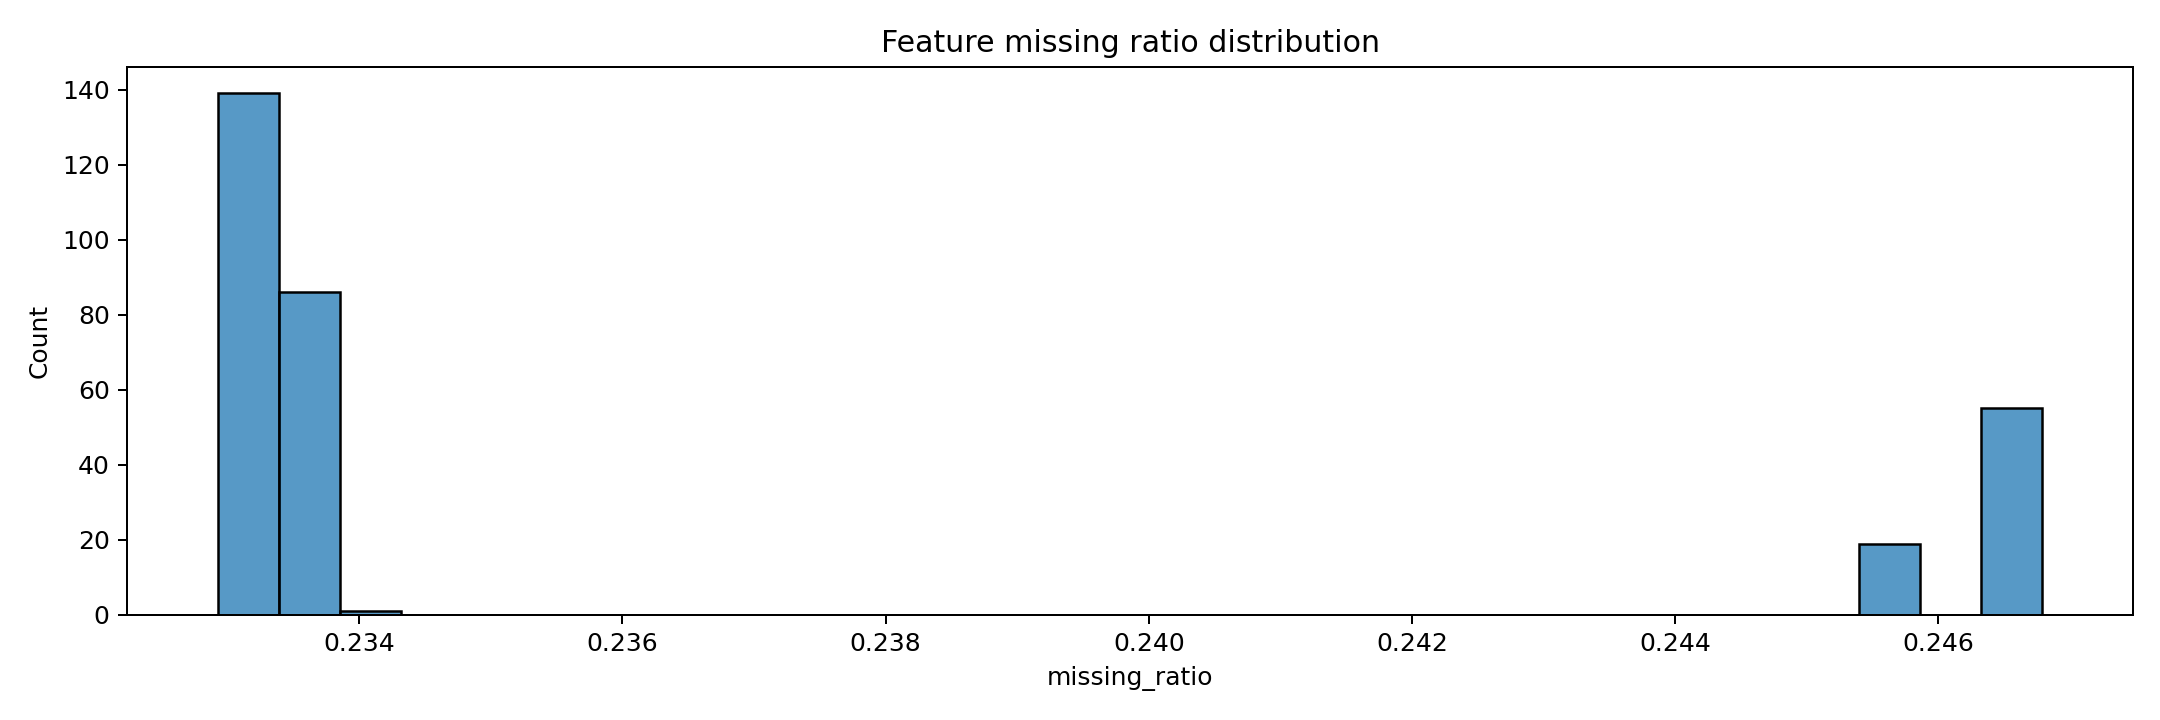

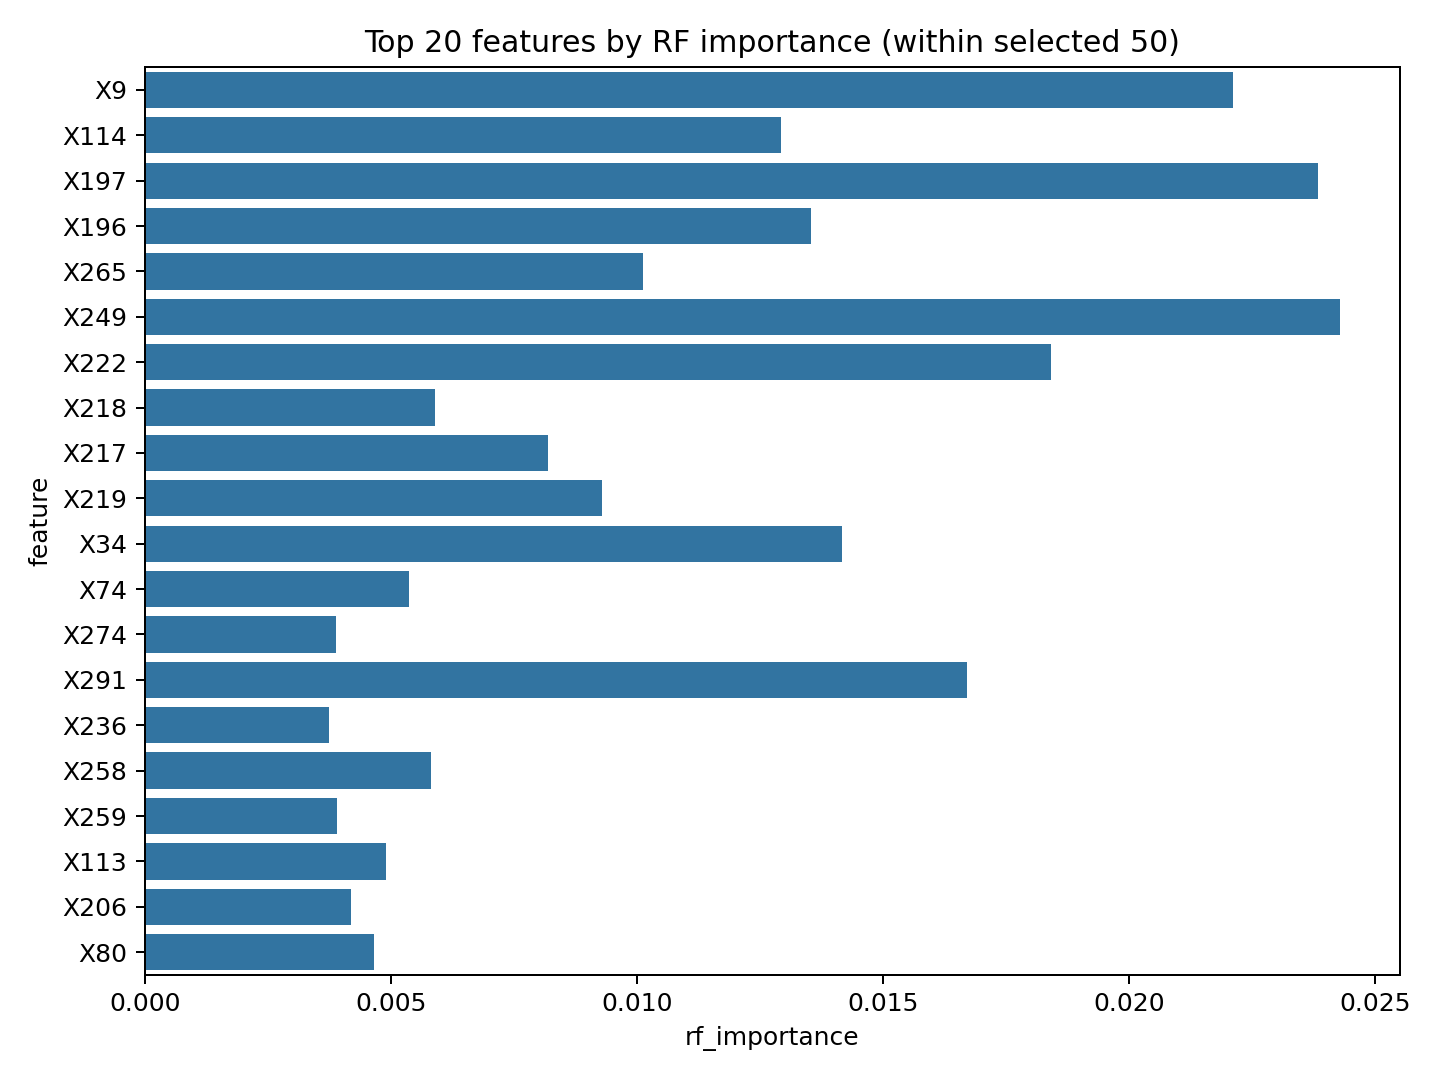

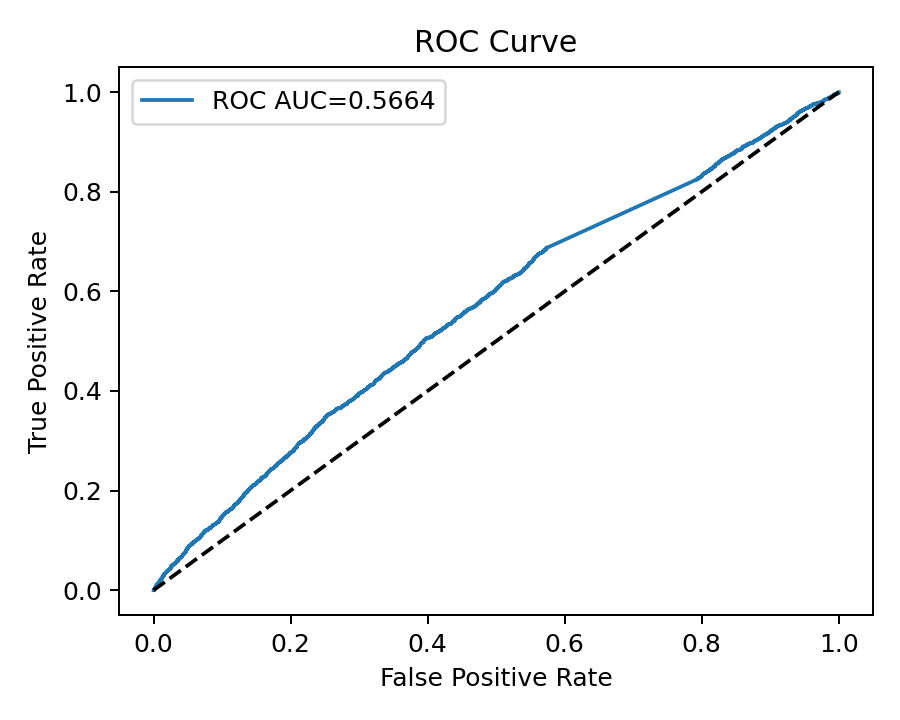

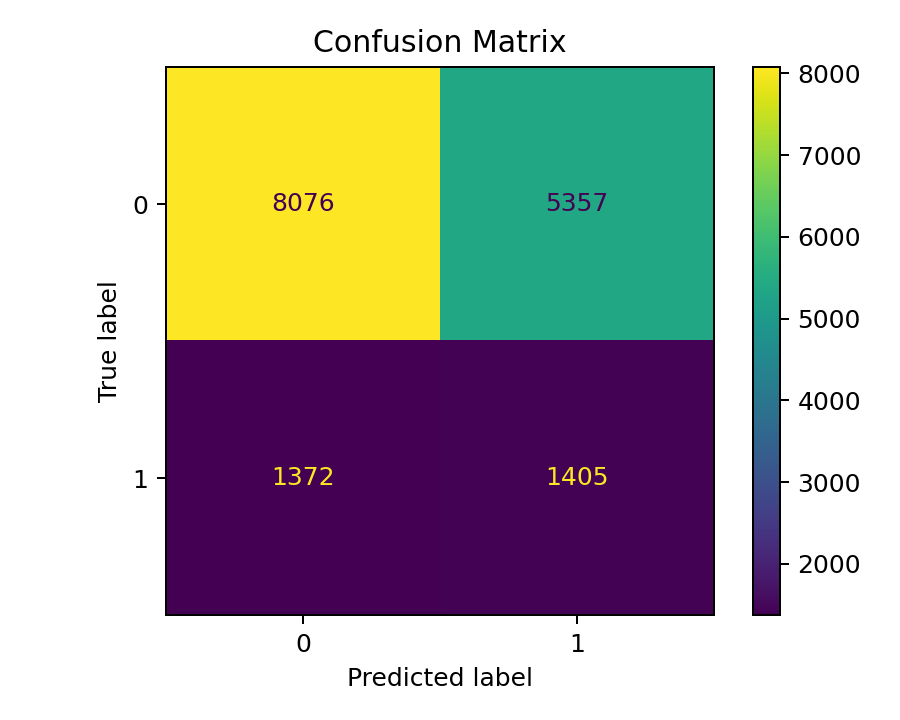

In [6]:

# 展示可视化结果
from IPython.display import Image, display

fig_dir = REPO_ROOT / 'Q2' / 'output' / 'figures'
for p in [
    fig_dir / 'missing_ratio_distribution.png',
    fig_dir / 'top20_feature_importance.png',
    fig_dir / 'roc_curve.png',
    fig_dir / 'confusion_matrix.png',
]:
    display(Image(filename=str(p)))


In [7]:

# 查看 Top50 及处理记录样例
import pandas as pd

top50 = pd.read_csv(REPO_ROOT / 'Q2' / 'output' / 'reports' / 'top50_features_with_scores.csv')
actions = pd.read_csv(REPO_ROOT / 'Q2' / 'output' / 'reports' / 'feature_cleaning_actions.csv')
print('Top50 预览:')
display(top50.head(10))
print('特征处理记录预览:')
display(actions.head(10))


Top50 预览:


,feature,mi,rf_importance,mi_rank,rf_rank,combined_rank
0,X9,0.010272,0.022123,2.0,4.0,3.0
1,X114,0.008515,0.012931,6.0,9.0,7.5
2,X197,0.007568,0.023841,14.0,3.0,8.5
3,X196,0.007608,0.013548,13.0,8.0,10.5
4,X265,0.008186,0.010129,9.0,13.0,11.0
5,X249,0.006182,0.024291,26.0,2.0,14.0
6,X222,0.006170,0.018427,27.0,5.0,16.0
7,X218,0.008264,0.005908,8.0,26.0,17.0
8,X217,0.007229,0.008192,16.0,20.0,18.0
9,X219,0.006735,0.009295,23.0,16.0,19.5


特征处理记录预览:


,feature,action,kept
0,X1,median_impute,True
1,X10,median_impute,True
2,X100,median_impute,True
3,X101,median_impute,True
4,X102,median_impute,True
5,X103,median_impute,True
6,X104,median_impute,True
7,X105,median_impute,True
8,X106,median_impute,True
9,X107,median_impute+winsorize_1_99,True


In [8]:

# 查看 agent 日志（前10行）
import pandas as pd

logs = pd.read_json(REPO_ROOT / 'Q2' / 'output' / 'logs' / 'agent_run_log.jsonl', lines=True)
display(logs.head(10))


,agent,action,detail,ts
0,orchestrator,load_data,{'data_dir': '/workspace/ai-data-science-team/...,2026-03-12T22:28:55.313108+00:00
1,orchestrator,data_loaded,"{'shape': [81046, 321]}",2026-03-12T22:28:59.637056+00:00
2,diagnosis_agent,diagnosis_complete,{'n_features': 300},2026-03-12T22:29:01.229782+00:00
3,cleaning_agent,cleaning_complete,"{'kept': 300, 'dropped': 0}",2026-03-12T22:29:04.050054+00:00
4,selection_agent,selection_complete,"{'top_k': 50, 'metrics': {'auc': 0.56644289195...",2026-03-12T22:31:52.764284+00:00
